In [1]:
import numpy as np
import pandas as pd
import zarr
import os
import matplotlib.pyplot as plt
plt.style.use('../libs/my_style.mplstyle')

OUTPUT_PATH = "/Users/sasakinozomu/code/MTCargo_analysis/notebooks/figures"

path = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122"

path0 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp"
path1 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp001"
path2 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002"
path3 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop'
path4 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1'

LPs = []
GPs = []

for p in [path0, path1, path2, path3, path4]:
    track_path = os.path.join(p, "beads_tracks_with_local_P.csv")
    tracks = pd.read_csv(track_path)
    LPs.extend(tracks['local_P'].values)

    globalP = os.path.join(p, "MTs_red_polar.zarr")
    GP_array = zarr.open_array(globalP, mode='r')
    GPs.extend(GP_array[:])

Text(0, 0.5, 'Density')

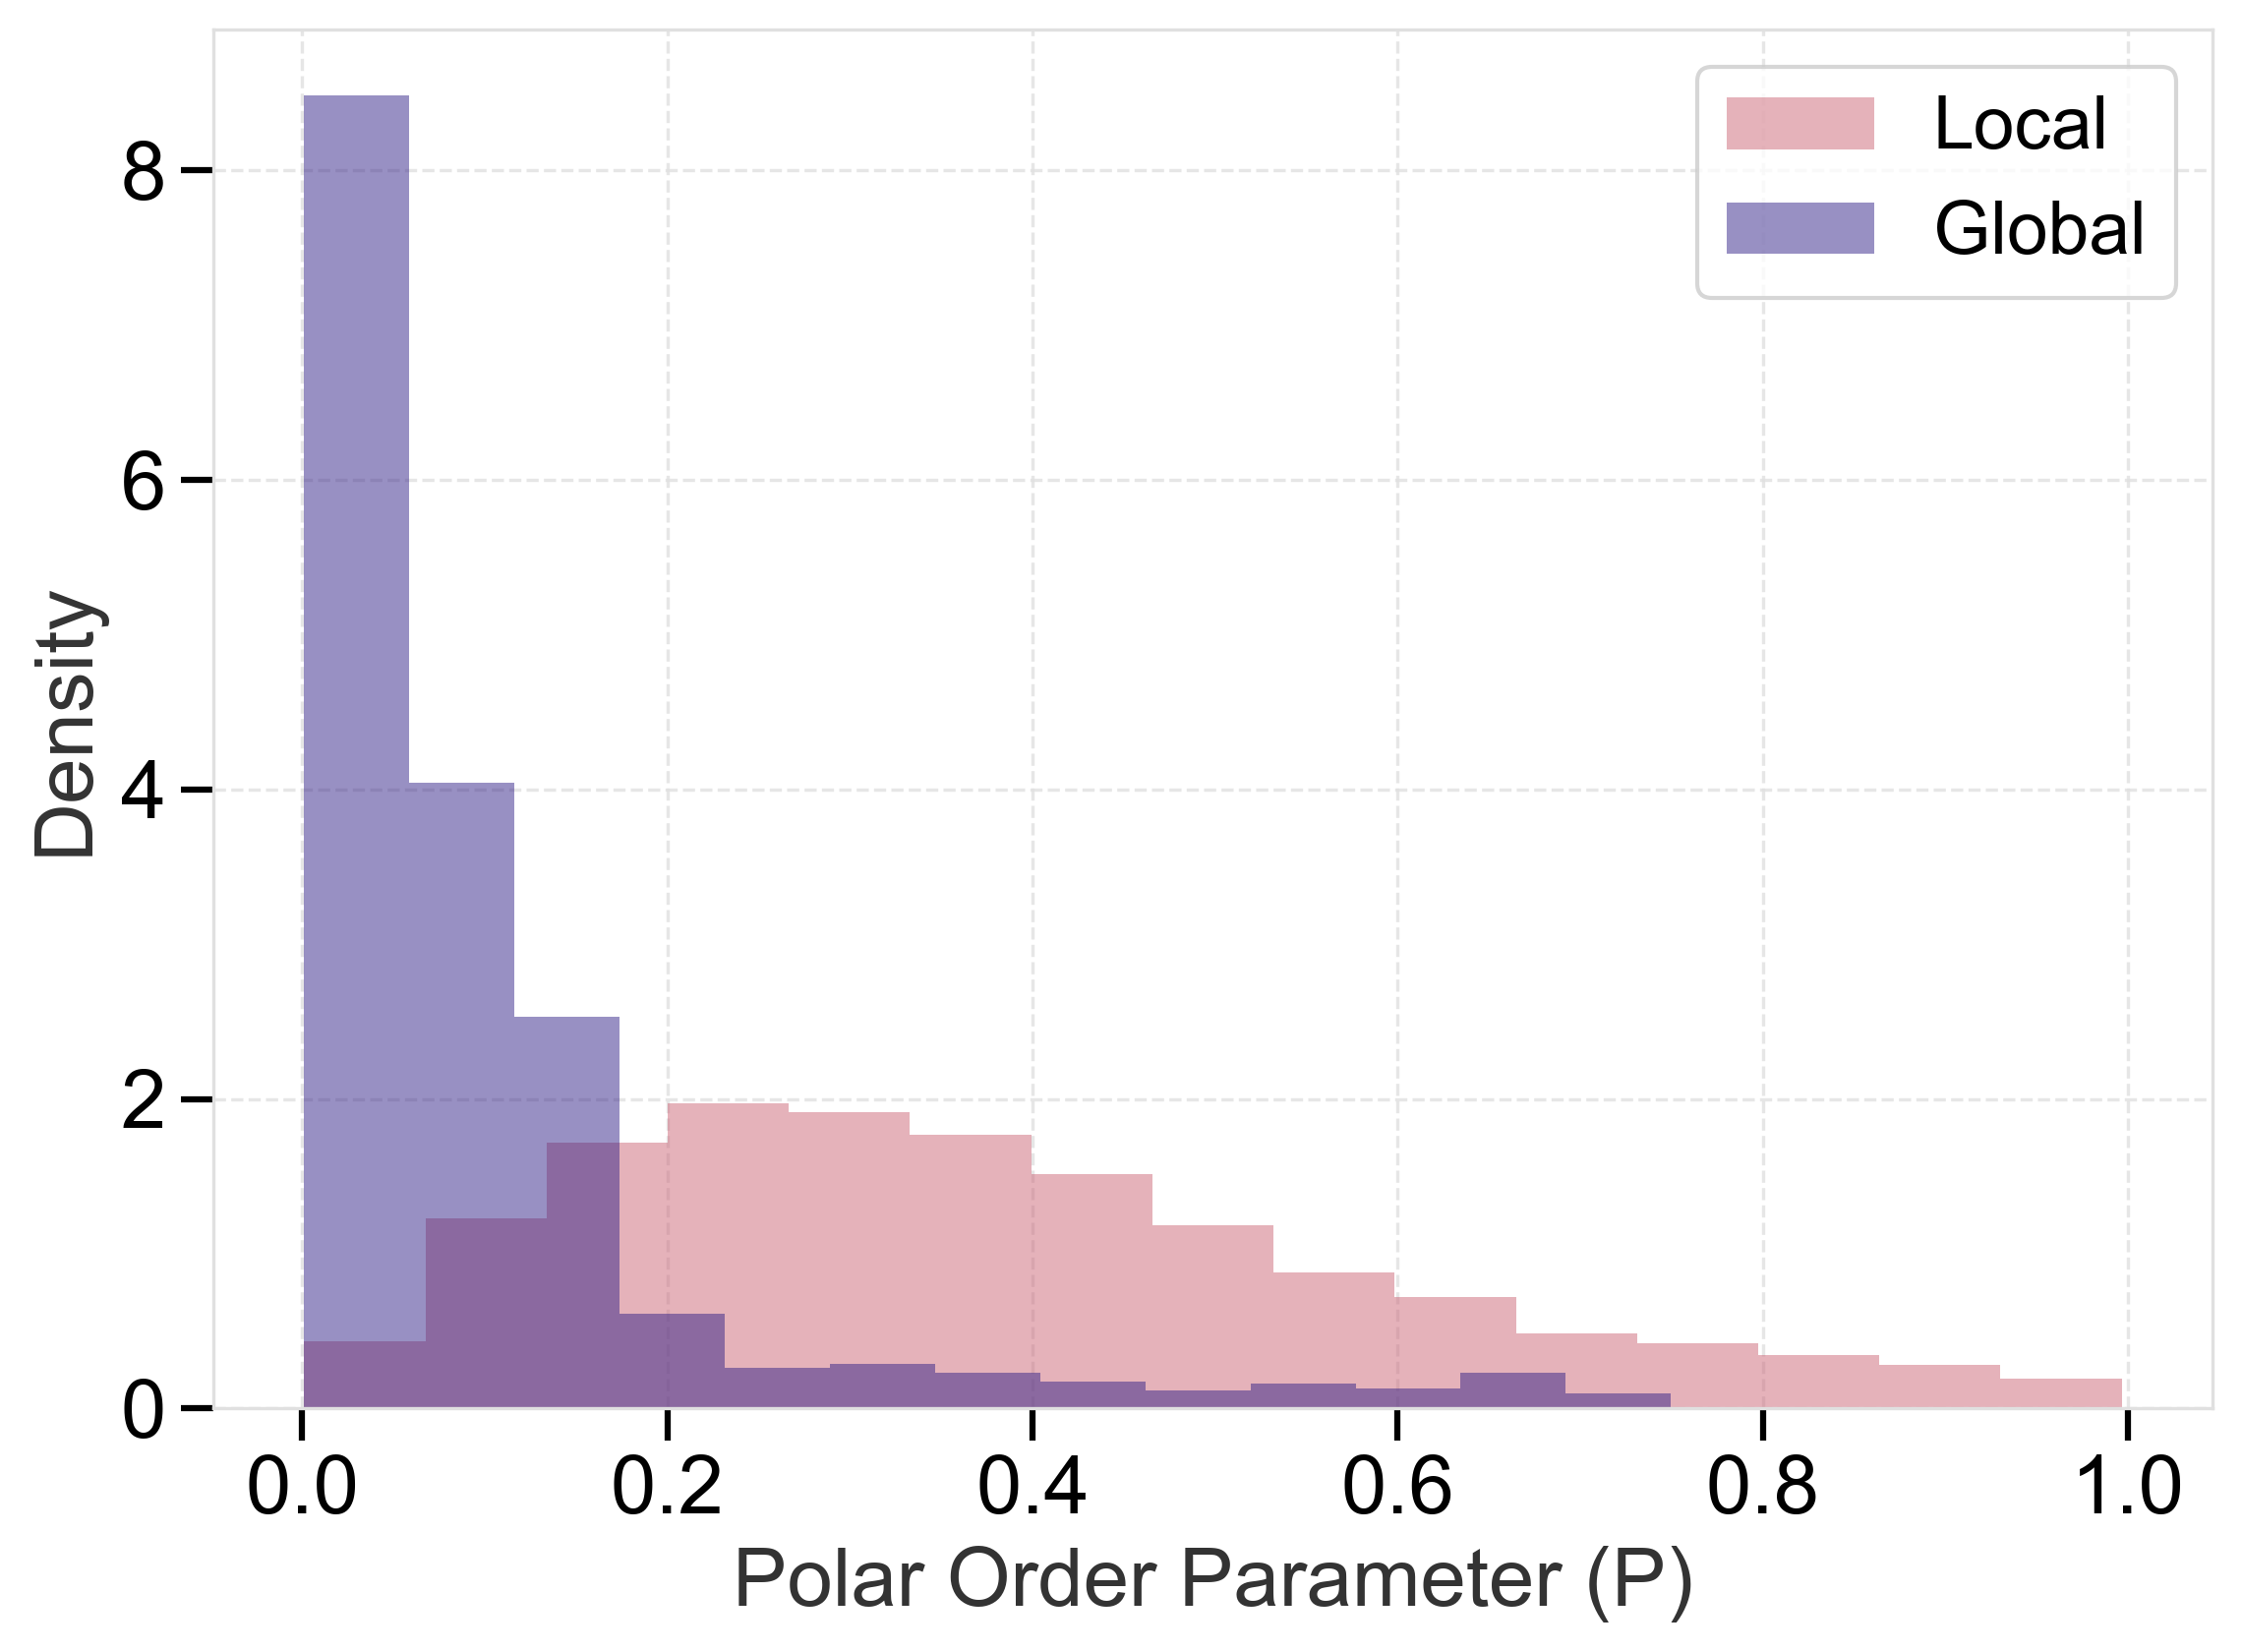

In [143]:
LPs_array = np.array(LPs)
GPs_array = np.array(GPs)
# Nanを除去
LPs_array = LPs_array[~np.isnan(LPs_array)]
GPs_array = GPs_array[~np.isnan(GPs_array)]

Lbins = np.histogram_bin_edges(LPs_array, bins='sturges')
Gbins = np.histogram_bin_edges(GPs_array, bins='sturges')

fig, ax = plt.subplots()

ax.hist(LPs_array, bins=Lbins, alpha=0.5, label='Local', density=True)
ax.hist(GPs_array, bins=Gbins, alpha=0.5, label='Global', density=True)
ax.legend()
ax.set_xlabel('Polar Order Parameter (P)')
ax.set_ylabel('Density')
#ax.set_title('Distribution of Polar Order Parameters')

In [144]:
output = os.path.join(OUTPUT_PATH, 'local_vs_global_P_distribution')

png = output + '.png'
pdf = output + '.pdf'

fig.savefig(png)
fig.savefig(pdf)

In [ ]:
interval = 4
GP_times = []
GP_all = []

for p in [path0, path1, path2, path3, path4]:
    globalP = os.path.join(p, "MTs_red_polar.zarr")
    GP_array = zarr.open_array(globalP, mode='r')
    GP_all.extend(GP_array[:])
    GP_times.extend(np.arange(GP_array.shape[0]) * interval)

GP_df = pd.DataFrame({
    't': GP_times,
    'P': GP_all
})

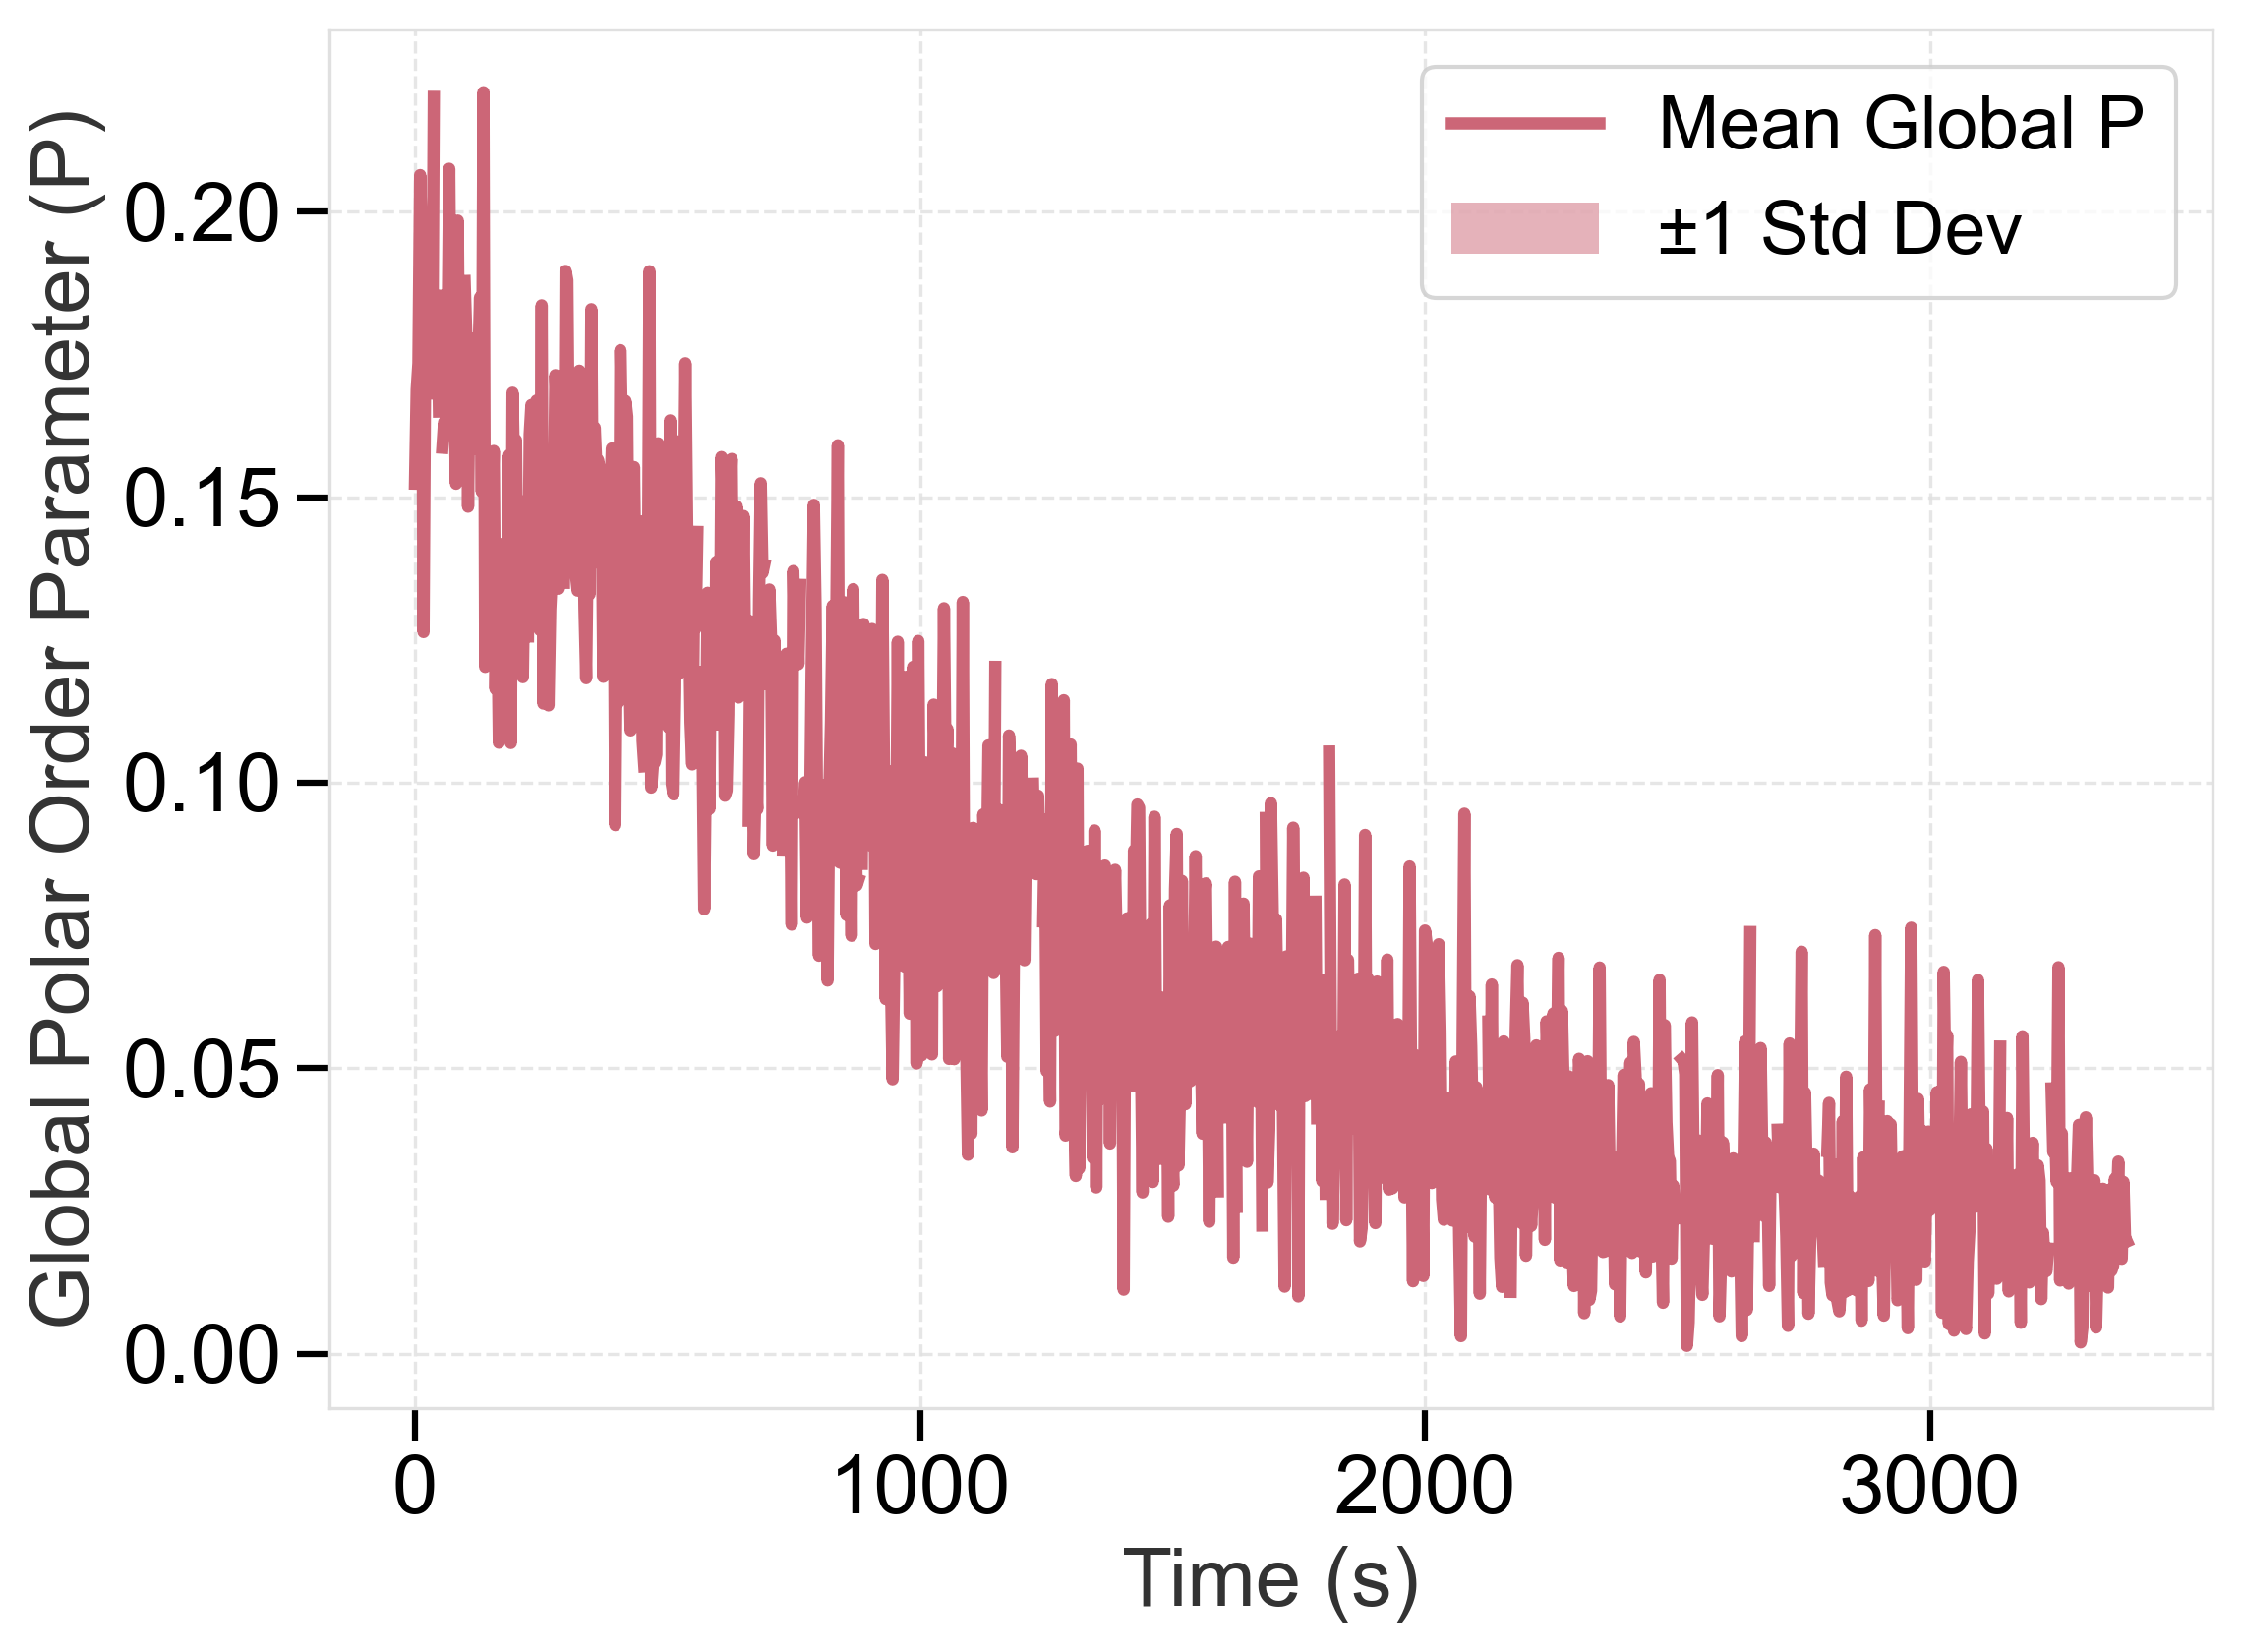

In [ ]:
tau = 1.18

mean_GP = GP_df.groupby('t').mean().reset_index()
std_GP = GP_df.groupby('t').std().reset_index()
fig, ax = plt.subplots()
ax.plot(mean_GP['t']/tau, mean_GP['P'], label='Mean Global P')
ax.fill_between(std_GP['t']/tau, mean_GP['P'] - std_GP['P'], mean_GP['P'] + std_GP['P'], alpha=0.5, label='±1 Std Dev')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Global Polar Order Parameter (P)')
ax.legend()